In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
data = pd.read_csv("Housing.csv")

data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [4]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [7]:
print(data['mainroad'].value_counts())

print(data['guestroom'].value_counts())

print(data['basement'].value_counts())

print(data['hotwaterheating'].value_counts())

print(data['airconditioning'].value_counts())

print(data['prefarea'].value_counts())

print(data['furnishingstatus'].value_counts())

mainroad
yes    468
no      77
Name: count, dtype: int64
guestroom
no     448
yes     97
Name: count, dtype: int64
basement
no     354
yes    191
Name: count, dtype: int64
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning
no     373
yes    172
Name: count, dtype: int64
prefarea
no     417
yes    128
Name: count, dtype: int64
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [8]:
mainroad = data['mainroad']
airconditioning = data['airconditioning']
furnishingstatus = data['furnishingstatus']
price = data['price']

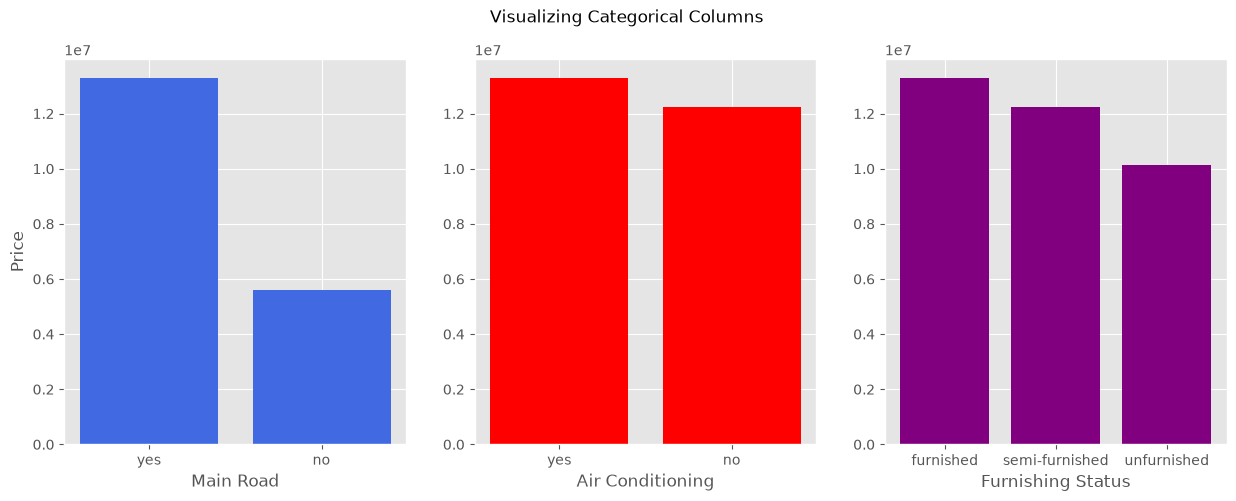

In [9]:
from matplotlib import style
style.use('ggplot')

fig = plt.figure(figsize=(15,5))
fig.suptitle('Visualizing Categorical Columns')

plt.subplot(1,3,1)
plt.bar(mainroad, price, color='royalblue')
plt.xlabel("Main Road")
plt.ylabel("Price")

plt.subplot(1,3,2)
plt.bar(airconditioning, price, color='red')
plt.xlabel("Air Conditioning")

plt.subplot(1,3,3)
plt.bar(furnishingstatus, price, color='purple')
plt.xlabel('Furnishing Status')

plt.show()

<Axes: xlabel='furnishingstatus', ylabel='price'>

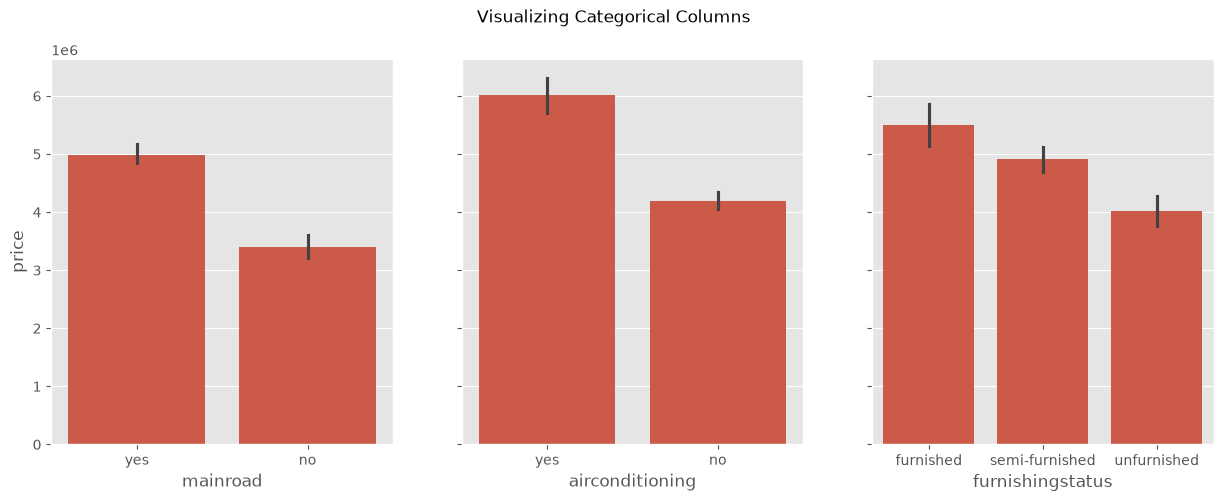

In [10]:
fig, axes = plt.subplots(1,3,figsize=(15,5), sharey=True)
fig.suptitle('Visualizing Categorical Columns')

sns.barplot(x=mainroad, y=price, ax=axes[0])
sns.barplot(x=airconditioning, y=price, ax=axes[1])
sns.barplot(x=furnishingstatus, y=price, ax=axes[2])

In [11]:
mainroad_data = data.groupby('mainroad').get_group('yes')
mainroad_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,4.680000e+02,468.000000,468.000000,468.000000,468.000000,468.000000
mean,4.991777e+06,5404.591880,2.961538,1.294872,1.848291,0.764957
std,1.893639e+06,2190.857014,0.721804,0.505447,0.902327,0.890282
min,1.750000e+06,1700.000000,1.000000,1.000000,1.000000,0.000000
25%,3.638250e+06,3733.750000,2.750000,1.000000,1.000000,0.000000
50%,4.550000e+06,4975.000000,3.000000,1.000000,2.000000,0.000000
75%,5.967500e+06,6542.500000,3.000000,2.000000,2.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [12]:
furnishing_data = data.groupby('furnishingstatus').get_group('furnished')
furnishing_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,1.400000e+02,140.000000,140.000000,140.000000,140.000000,140.000000
mean,5.495696e+06,5688.100000,3.064286,1.378571,1.942857,0.885714
std,2.117857e+06,2409.000994,0.788503,0.542680,0.965382,0.898325
min,1.750000e+06,2145.000000,1.000000,1.000000,1.000000,0.000000
25%,3.876250e+06,3640.000000,3.000000,1.000000,1.000000,0.000000
50%,5.075000e+06,5800.000000,3.000000,1.000000,2.000000,1.000000
75%,6.650000e+06,6947.500000,3.000000,2.000000,2.000000,2.000000
max,1.330000e+07,13200.000000,6.000000,4.000000,4.000000,3.000000


In [13]:
data.replace({'mainroad':{'yes':1, 'no':0}}, inplace=True)
data.replace({'guestroom':{'yes':1, 'no':0}}, inplace=True)
data.replace({'basement':{'yes':1, 'no':0}}, inplace=True)
data.replace({'hotwaterheating':{'yes':1, 'no':0}}, inplace=True)
data.replace({'airconditioning':{'yes':1, 'no':0}}, inplace=True)
data.replace({'prefarea':{'yes':1, 'no':0}}, inplace=True)
data.replace({'furnishingstatus':{'furnished':0, 'semi-furnished':1, 'unfurnished':2}}, inplace=True)

data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


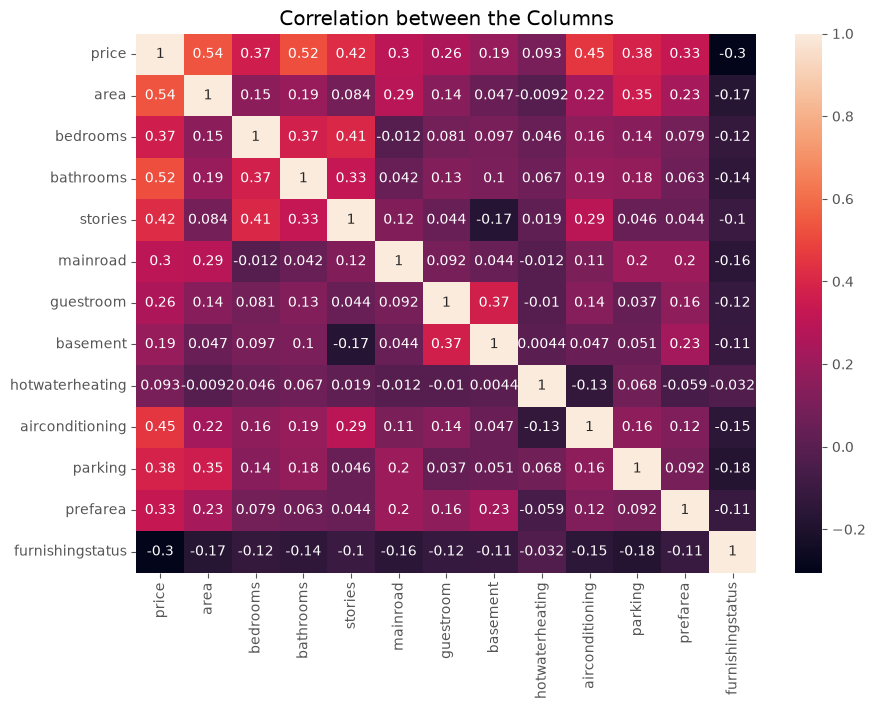

In [14]:
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(), annot=True)
plt.title('Correlation between the Columns')
plt.show()

<Axes: title={'center': 'Correlation between Area and Price'}, xlabel='area', ylabel='price'>

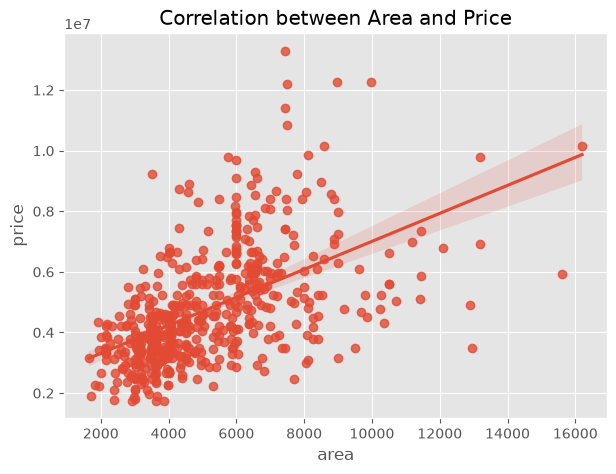

In [15]:
fig = plt.figure(figsize=(7,5))
plt.title('Correlation between Area and Price')
sns.regplot(x='area', y='price', data=data)

In [16]:
X = data.drop(['price'], axis=1)
y = data["price"]

X.shape

(545, 12)

In [17]:
y.shape

(545,)

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=43)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
linreg = LinearRegression()

In [22]:
linreg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 564508.76, 94939.05, 463032.41,..., 200470.6 , 291294.54,-167981.66]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.811e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](12,)","[30.49,24.31,22.17,...,15.56,14.44,12.68]"


In [23]:
y_pred = linreg.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE: ", (mean_absolute_error(y_pred, y_test)))
print("MSE: ", (mean_squared_error(y_pred, y_test)))
print("R2 score: ", (r2_score(y_pred, y_test)))

MAE:  883601.1150391462
MSE:  1495698926593.6924
R2 score:  0.4209231073348123


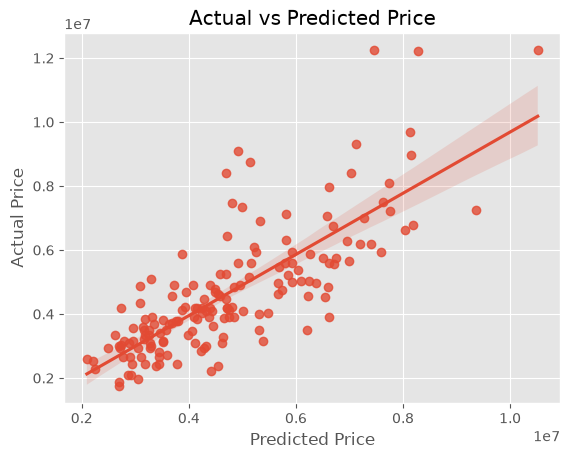

In [25]:
sns.regplot(x=y_pred, y=y_test)
plt.xlabel("Predicted Price")
plt.ylabel('Actual Price')
plt.title("Actual vs Predicted Price")
plt.show()

In [26]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_test, y_pred)
print( accuracy)


0.6110312568234624
